In [1]:
import os, getpass

def _set_env(var:str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

In [ ]:
from langchain_openai import ChatOpenAI

def multiply(a: int, b : int) -> int:
    """Multiply a and b.
    
    Args:
        a : first int
        b : second int 
    """
    return a * b

def add(a: int, b : int) -> int:
    """Adds a and b.
    
    Args:
       a : first int
       b : Second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add, multiply, divide]
tools


[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.divide(a: int, b: int) -> float>]

In [6]:
llm = ChatOpenAI(
    model= "gpt-4o-mini"
)
llm_with_tools = llm.bind_tools(tools)
llm_with_tools

_ChatModelBinding(bound=ChatOpenAI(metadata={'lc_versions': {'langchain-core': '1.4.9', 'langchain': '1.3.14', 'langchain-openai': '1.3.5'}}, output_version=None, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True, 'tool_call_streaming': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x11e007750>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x11e064190>, root_client=<openai.Open

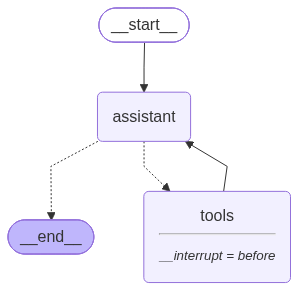

In [11]:
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

system_smg = SystemMessage(
    content="You are a helpful assistant tasked with performing arithmetic on a set of inputs"
)

def assistant(state: MessagesState):
    return {
        "messages": [llm_with_tools.invoke([system_smg] + state["messages"])]
    }

builder = StateGraph(MessagesState)

builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition
)
builder.add_edge("tools", "assistant")

memory = MemorySaver()
graph = builder.compile(
    interrupt_before=["tools"], 
    checkpointer=memory
)

display(
    Image(
        graph.get_graph(xray=True).draw_mermaid_png()
        )
)

In [12]:
initial_input = {
    'messages' : HumanMessage(content="Multiply 2 and 3")
}

thread = {
    'configurable' : {'thread_id' : '1'}
}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_fZLRwc1vzP7YeAJVIv4kuBsn)
 Call ID: call_fZLRwc1vzP7YeAJVIv4kuBsn
  Args:
    a: 2
    b: 3


In [13]:
state = graph.get_state(thread)
state.next

('tools',)

In [14]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  multiply (call_fZLRwc1vzP7YeAJVIv4kuBsn)
 Call ID: call_fZLRwc1vzP7YeAJVIv4kuBsn
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

The result of multiplying 2 and 3 is 6.


In [15]:
initial_input = {"messages": HumanMessage(content="Multiply 2 and 3")}

thread = {"configurable": {"thread_id": "2"}}

for event in graph.stream(initial_input, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

user_approval = input("Do you want to call the tool? (yes/no): ")

if user_approval.lower() == "yes":
    
    for event in graph.stream(None, thread, stream_mode="values"):
        event['messages'][-1].pretty_print()
        
else:
    print("Operation cancelled by user.")

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (call_2fvyxymaRNqOOAiBJ5D0Uj4Z)
 Call ID: call_2fvyxymaRNqOOAiBJ5D0Uj4Z
  Args:
    a: 2
    b: 3
Operation cancelled by user.
